In [1]:
import matplotlib
matplotlib.use('Agg')  # Backend non-interactif
%matplotlib inline

import matplotlib.pyplot as plt
import os
import glob
import numpy as np
import astropy.units as u
import random
import pandas as pd
import copy
import json
import numba

from tqdm.auto import tqdm
from textwrap import fill
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.coordinates import search_around_sky
from matplotlib.patches import Rectangle
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from sklearn.model_selection import train_test_split
import matplotlib.colors as colors
from astropy.coordinates import angular_separation
import astropy.units as u
from astropy.table import join
from collections import Counter

from constantes import LIM_FLUX_CLUSTER, LIM_FLUX_AGN, SEARCH_RADIUS_CLUSTER, SEARCH_RADIUS_AGN, WINDOW_SIZE_ARCMIN, NOMBRE_PHOTONS_MIN, MAX_Xamin_PAR_FENESTRON
from constantes import print_parameters

print_parameters()


/local/home/sh275430/mon_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


╭───────────────────────────────────────────────╮
│                   PARAMÈTRES                  │
├───────────────────────────────────────────────┤
│ LIM_FLUX_CLUSTER        : 1.00e-15 erg/cm²/s 
│ LIM_FLUX_AGN            : 1.00e-15 erg/cm²/s 
│ SEARCH_RADIUS_CLUSTER   : 20.00    arcsec    
│ SEARCH_RADIUS_AGN       : 10.00    arcsec    
│ EXT_LIKE_C1             : 33       
│ EXT_LIKE_C2             : 15       
│ EXT_C1_C2               : 5        arcsec    
│ EXT_LIKE_C1_new         : 80       
│ EXT_LIKE_C2_new         : 35       
│ EXT_C1_C2_new           : 13       arcsec    
│ window_size             : 2.0      arcmin    
│ MAX_Xamin_PAR_FENESTRON : 2        
│ PNT_DET_ML_SPURIOUS     : 20       
│ EXT_LIKE_SPURIOUS       : 15       
│ NOMBRE_PHOTONS_MIN      : 100      photons   
╰───────────────────────────────────────────────╯


# **Choix des donnees**

In [2]:
Simulation1 = True
Simulation2 = False
Simulation3 = False

if(Simulation1):
    name_dir = 'Simulation1'
    catalog_path_aftXamin = os.path.expanduser('~/Documents/TransformerProject/data/Simulation1/Xamin_stack_fxabs2e-16/merged_catalog_cleaned.fits')

if(Simulation2):
    name_dir = 'Simulation2'
    catalog_path_aftXamin = os.path.expanduser('~/Documents/TransformerProject/data/Simulation2/fsII_25_lensed_AGN1/Xamin_onlyMOSPN/merged_catalog_cleaned.fits')

if(Simulation3):
    name_dir = 'Simulation3'
    catalog_path_aftXamin = os.path.expanduser('~/Documents/TransformerProject/data/Simulation3/fsII_25_lensed_AGN2/Xamin_onlyMOSPN/merged_catalog_cleaned.fits')

catalog_path_AMAS  = os.path.expanduser(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/AMAS_matches_r{SEARCH_RADIUS_CLUSTER*3600:.0f}arcsec_flux{LIM_FLUX_CLUSTER}_40ks.fits')
catalog_path_AGN  = os.path.expanduser(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/AGN_matches_r{SEARCH_RADIUS_AGN*3600:.0f}arcsec_flux{LIM_FLUX_AGN}_40ks.fits')

path_list_ID_Xamin_AMAS = f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/list_ID_Xamin_AMAS_matches_r{SEARCH_RADIUS_CLUSTER*3600:.0f}arcsec_flux{LIM_FLUX_CLUSTER}_40ks.fits'
path_list_ID_Xamin_AGN  = f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/list_ID_Xamin_AGN_matches_r{SEARCH_RADIUS_AGN*3600:.0f}arcsec_flux{LIM_FLUX_AGN}_40ks.fits'

# **Chargements des fichiers**

In [3]:
data_Xamin = Table.read(catalog_path_aftXamin)
data_AMAS  = Table.read(catalog_path_AMAS)
data_AGN   = Table.read(catalog_path_AGN)

data_Xamin['new_ID'] = np.arange(len(data_Xamin))
data_Xamin['Ntot'] = data_Xamin['INST0_EXP'] * data_Xamin['PNT_RATE_MOS'] + data_Xamin['INST1_EXP'] * data_Xamin['PNT_RATE_PN']
print(f"\033[1mNombre de sources Xamin:\033[0m\nAvant la coupe sur le nombre de photons: \033[1m{len(data_Xamin)}\033[0m")
data_Xamin = data_Xamin[data_Xamin['Ntot']>=NOMBRE_PHOTONS_MIN]
print(f"Apres la coupe sur le nombre de photons: \033[1m{len(data_Xamin)}\033[0m")
print(f"\nRappel: NOMBRE_PHOTONS_MIN = {NOMBRE_PHOTONS_MIN} photons")

list_ID_Xamin_AMAS = np.loadtxt(path_list_ID_Xamin_AMAS, dtype=int)
list_ID_Xamin_AGN  = np.loadtxt(path_list_ID_Xamin_AGN, dtype=int)

Nombre de sources Xamin:
Avant la coupe sur le nombre de photons: 25319
Apres la coupe sur le nombre de photons: 7316

Rappel: NOMBRE_PHOTONS_MIN = 100 photons


In [4]:
data_AMAS[0]

3,ID,R.A.,Dec,px,yx,m200,Tsl,Lx_soft,flux,flux_ABS,r500,z
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
22,4536364099,150.764948909833,5.8413753004472,6490.06355365396,6618.59372723584,68548001000000,2.68,3.2e+42,3.65e-15,3.15e-15,36.0,0.4842


In [5]:

data_AGN[0]

id,ra_mag_gal,dec_mag_gal,z,m,passive,agn_type,Lx_h,Lx_s,Fx_s_abs,Fx_s_G14,NH,Mbh
int64,float32,float32,float32,float32,int32,int32,float32,float32,float32,float32,float32,float32
35353500011970000,150.84576,1.9766083,0.003286787,7.7614284,0,2,39.93776,39.478336,4.417671e-15,1.2650335e-13,22.95448,0.0150628565


# **Choix des variables traitees par le Transformer**

In [6]:
VOCAB_SIZE = 1029 # Tokens valides: 0-1023 = 1024 tokens + 3 tokens speciaux
PAD_TOKEN  = 1024  # Padding
SEP_TOKEN  = 1025  # Marque la fin de la sequence
CLS_TOKEN  = 1026  # Marque le debut de la sequence
SEP_AMAS   = 1027 # Marque le debut du catalogue AMAS
SEP_AGN    = 1028 # Marque le debut du catalogue AGN

NOMBRE_TOKENS_SPECIAUX = 5

In [7]:
#SELECTED_COLUMNS_Xamin = ['EXT_LIKE', 'EXT', 'EXT_RA', 'EXT_DEC' ,'PNT_DET_ML', 'PNT_RA', 'PNT_DEC', 'PNT_RATE_MOS', 'PNT_RATE_PN']
SELECTED_COLUMNS_Xamin = ['EXT_LIKE', 'EXT', 'EXT_RA', 'EXT_DEC' ,'PNT_DET_ML']

SELECTED_COLUMNS_input_clusters = ['R.A.', 'Dec']
SELECTED_COLUMNS_input_AGN = ['ra_mag_gal', 'dec_mag_gal']

print(f'Nombre de colonnes SELECTED_COLUMNS_Xamin: {len(SELECTED_COLUMNS_Xamin)}')
print(f'Nombre de colonnes SELECTED_COLUMNS_input_clusters: {len(SELECTED_COLUMNS_input_clusters)}')
print(f'Nombre de colonnes SELECTED_COLUMNS_input_AGN: {len(SELECTED_COLUMNS_input_AGN)}')

Nombre de colonnes SELECTED_COLUMNS_Xamin: 5
Nombre de colonnes SELECTED_COLUMNS_input_clusters: 2
Nombre de colonnes SELECTED_COLUMNS_input_AGN: 2


In [8]:
#use_log_scale_Xamin = [True, True, False, False, True, False, False, True, True]
use_log_scale_Xamin = [True, True, False, False, True]
use_log_scale_input_clusters = [False, False]
use_log_scale_input_AGN = [False, False]

print(f'Nombre de colonnes use_log_scale_Xamin: {len(use_log_scale_Xamin)}')
print(f'Nombre de colonnes use_log_scale_input_clusters: {len(use_log_scale_input_clusters)}')
print(f'Nombre de colonnes use_log_scale_input_AGN: {len(use_log_scale_input_AGN)}')

Nombre de colonnes use_log_scale_Xamin: 5
Nombre de colonnes use_log_scale_input_clusters: 2
Nombre de colonnes use_log_scale_input_AGN: 2


# **Separation des donnees d'entrainement et test**

Il est necessaire d'avoir des jeux de donnees independants pour le jeu d entrainement et le jeu test. On separe en deux les 25deg2 avec la limite en declinaison DEC_LIM_FOR_TRAINING 

In [9]:
DEC_LIM_FOR_TRAINING = 2.15 # en degres 
                          # 2deg-> 0.75deg de largeur en dec pour le test sur 1deg en ra

**Amas**

In [10]:
mask_for_training = data_AMAS['Dec'] > DEC_LIM_FOR_TRAINING # en degres

data_AMAS_train = data_AMAS[mask_for_training]
data_AMAS_test  = data_AMAS[~mask_for_training]

pourcentage_train = len(data_AMAS_train)*100/len(data_AMAS)
pourcentage_test  = len(data_AMAS_test) *100/len(data_AMAS)

print(f"Nombre total d'amas: {len(data_AMAS)}")
print(f"Zone train: {len(data_AMAS_train)} >> {pourcentage_train:.1f}%")
print(f"Zone test:  {len(data_AMAS_test)} >> {pourcentage_test:.1f}%")

Nombre total d'amas: 285
Zone train: 232 >> 81.4%
Zone test:  53 >> 18.6%


**AGN**

In [11]:
mask_for_training = data_AGN['dec_mag_gal'] > DEC_LIM_FOR_TRAINING # en degres

data_AGN_train = data_AGN[mask_for_training]
data_AGN_test  = data_AGN[~mask_for_training]

pourcentage_train = len(data_AGN_train)*100/len(data_AGN)
pourcentage_test  = len(data_AGN_test) *100/len(data_AGN)

print(f"Nombre total d'AGN: {len(data_AGN)}")
print(f"Zone train: {len(data_AGN_train)} >> {pourcentage_train:.1f}%")
print(f"Zone test:  {len(data_AGN_test)} >> {pourcentage_test:.1f}%")

Nombre total d'AGN: 7383
Zone train: 5937 >> 80.4%
Zone test:  1446 >> 19.6%


**Xamin**

In [12]:
mask_for_training = data_Xamin['PNT_DEC'] > DEC_LIM_FOR_TRAINING # en degres

data_Xamin_train = data_Xamin[mask_for_training]
data_Xamin_test  = data_Xamin[~mask_for_training]

print(f"Nombre total Xamin: {len(data_Xamin)}")
print(f"Zone train: {len(data_Xamin_train)} >> {len(data_Xamin_train) *100/len(data_Xamin):.1f}%")
print(f"Zone test:  {len(data_Xamin_test)} >> {len(data_Xamin_test) *100/len(data_Xamin):.1f}%")

Nombre total Xamin: 7316
Zone train: 5886 >> 80.5%
Zone test:  1430 >> 19.5%


# **Selection des fenetres**

On cree une liste d'ID_Xamin, sur lequel on va ensuite centrer les fenetres sur chacune de ses sources, qui melange amas et autres

In [13]:
def CreateListID_Xamin(all_xamin_ids, list_id_xamin_amas, proportion=1):
    """
    Creates a combined list of IDs by taking the intersection of two ID lists
    and adding a random subset of IDs from the remaining IDs in `all_xamin_ids`
    that are not in `list_id_xamin_amas`, scaled by a given proportion.

    Args:
        all_xamin_ids (np.ndarray or list): Full list of IDs.
        list_id_xamin_amas (np.ndarray or list): Reference subset of IDs.
        proportion (float, optional): Proportion of additional IDs to add 
                                      (relative to the number of common IDs). Default is 1.0.

    Returns:
        np.ndarray: Combined array of IDs.
    """

    # Trouver les IDs communs
    common_ids = np.intersect1d(list_id_xamin_amas, all_xamin_ids)

    # Trouver les IDs disponibles pour le tirage aléatoire (ceux qui ne sont PAS dans list_id_xamin_amas)
    available_ids = np.setdiff1d(all_xamin_ids, list_id_xamin_amas)

    # Nombre d'IDs à ajouter = nombre d'IDs communs
    n_additional = int(proportion * len(common_ids))  # % du nombre d'IDs communs

    if len(available_ids) >= n_additional: # Tirage aléatoire sans remise
        random_ids = np.random.choice(available_ids, size=n_additional, replace=False)
    else:
        random_ids = available_ids  # Si pas assez d'IDs disponibles

    # Combinaison finale
    combined_ids = np.concatenate([common_ids, random_ids])

    return combined_ids

In [14]:
AllXaminSources = False

if(AllXaminSources):
    list_ID_Xamin_train = data_Xamin_train['ID_Xamin']
    list_ID_Xamin_test  = data_Xamin_test['ID_Xamin']
else:
    list_ID_Xamin_train = CreateListID_Xamin(np.array(data_Xamin_train['ID_Xamin']), list_ID_Xamin_AMAS)
    list_ID_Xamin_test  = CreateListID_Xamin(np.array(data_Xamin_test['ID_Xamin']), list_ID_Xamin_AMAS)


In [15]:
print(f"Jeu train: {len(list_ID_Xamin_train)}")
print(f"Jeu test:  {len(list_ID_Xamin_test)}")

Jeu train: 460
Jeu test:  108


# **Construction des fenetres**

In [16]:
def Batisseuse2Fenetres(data_Xamin, data_clusters, data_AGN, list_ID_Xamin, 
                        cluster_columns_to_keep = ['window', 'R.A.', 'Dec', 'm200', 'z'],
                        #AGN_columns_to_keep = ['window', 'ra_mag_gal', 'dec_mag_gal', 'observed_redshift_gal', 'log_stellar_mass_h70'],
                        AGN_columns_to_keep = ['window', 'ra_mag_gal', 'dec_mag_gal'],
                        window_size_arcmin = WINDOW_SIZE_ARCMIN):
    """
    Extracts sources, clusters, and AGNs within windows centered on Xamin IDs.
    Recenters RA and Dec coordinates relative to window centers and sorts by separation.
    
    Args:
        data_Xamin (Astropy Table or similar): Xamin sources catalog with columns including 'PNT_RA', 'PNT_DEC', 'ID_Xamin'.
        data_clusters (Astropy Table): Cluster catalog with columns including 'R.A.', 'Dec', etc.
        data_AGN (Astropy Table): AGN catalog with columns including 'ra_mag_gal', 'dec_mag_gal', etc.
        list_ID_Xamin (list or array): List of Xamin IDs defining window centers.
        cluster_columns_to_keep (list): Columns to keep from clusters.
        AGN_columns_to_keep (list): Columns to keep from AGNs.
        window_size_arcmin (float): Size of each window in arcminutes.
        
    Returns:
        tuple: (selected_sources, selected_clusters, selected_AGN) stacked tables with recentered coords and window info.
    """

    coords = SkyCoord(ra=data_Xamin['PNT_RA']*u.deg, dec=data_Xamin['PNT_DEC']*u.deg)
    half_size_deg = (window_size_arcmin / 60) / 2
    
    selected_src = [] # Liste pour stocker toutes les lignes sélectionnées
    selected_clusters = []
    selected_AGN = []
    
    for window_num, id in enumerate(list_ID_Xamin):

        # Coordonnees du centre de la fenetre
        ra_center  = data_Xamin[data_Xamin['ID_Xamin'] == id]['PNT_RA']
        dec_center = data_Xamin[data_Xamin['ID_Xamin'] == id]['PNT_DEC']
        center = SkyCoord(ra_center*u.deg, dec_center*u.deg)

        delta_ra  = np.abs(coords.ra.deg - ra_center)
        delta_dec = np.abs(coords.dec.deg - dec_center)
        delta_ra  = np.minimum(delta_ra, 360 - delta_ra)
        
        mask_Xamin_in_window = (delta_ra < half_size_deg) & (delta_dec < half_size_deg)

        # Pour les sources dans cette fenêtre, calculer leur distance au centre
        sources_in_window = data_Xamin[mask_Xamin_in_window]
        
        if len(sources_in_window) > 0:
            sources_coords = SkyCoord(ra=sources_in_window['PNT_RA']*u.deg, dec=sources_in_window['PNT_DEC']*u.deg)
            separations = sources_coords.separation(center)

            # Ajouter la séparation comme colonne temporaire
            sources_in_window = sources_in_window.copy()
            sources_in_window['separation_deg'] = separations.deg
            sources_in_window['window'] = window_num

            # Recentrage des coordonnées Xamin
            for suffix in ['EXT', 'PNT', 'DBL', 'EPN']:
                ra_col = f"{suffix}_RA"
                dec_col = f"{suffix}_DEC"
                
                if ra_col in sources_in_window.colnames and dec_col in sources_in_window.colnames:
                    orig_coords = SkyCoord(ra=sources_in_window[ra_col]*u.deg, 
                                         dec=sources_in_window[dec_col]*u.deg)
                    dra, ddec = orig_coords.spherical_offsets_to(center)
                    sources_in_window[ra_col] = dra.to(u.deg).value
                    sources_in_window[dec_col] = ddec.to(u.deg).value

            sources_in_window.sort('separation_deg') # Trier par distance au centre

            selected_src.append(sources_in_window) # Ajouter aux lignes sélectionnées

        # CLUSTERS PART

        coords_clusters = SkyCoord(ra=data_clusters['R.A.']*u.deg, dec=data_clusters['Dec']*u.deg)

        delta_ra_clusters  = np.abs(coords_clusters.ra.deg - ra_center)
        delta_dec_clusters = np.abs(coords_clusters.dec.deg - dec_center)
        delta_ra_clusters  = np.minimum(delta_ra_clusters, 360 - delta_ra_clusters)
        
        mask_clusters_in_window = (delta_ra_clusters < half_size_deg) & (delta_dec_clusters < half_size_deg)

        clusters_in_window = data_clusters[mask_clusters_in_window]

        if len(clusters_in_window) > 0:
            sources_coords_clusters = SkyCoord(ra=clusters_in_window['R.A.']*u.deg, dec=clusters_in_window['Dec']*u.deg)
            separations = sources_coords_clusters.separation(center)
            
            # Ajouter la séparation comme colonne temporaire
            clusters_in_window = clusters_in_window.copy()
            clusters_in_window['separation_deg'] = separations.deg
            clusters_in_window['window'] = window_num

            ra_col = "R.A."
            dec_col = "Dec"
            
            if ra_col in clusters_in_window.colnames and dec_col in clusters_in_window.colnames:
                orig_coords = SkyCoord(ra=clusters_in_window[ra_col]*u.deg, 
                                        dec=clusters_in_window[dec_col]*u.deg)
                dra, ddec = orig_coords.spherical_offsets_to(center)
                clusters_in_window[ra_col] = dra.to(u.deg).value
                clusters_in_window[dec_col] = ddec.to(u.deg).value

            clusters_in_window.sort('separation_deg') # Trier par distance au centre
            clusters_in_window = clusters_in_window[cluster_columns_to_keep]

            selected_clusters.append(clusters_in_window) # Ajouter aux lignes sélectionnées

        
        # AGN PART

        coords_AGN = SkyCoord(ra=data_AGN['ra_mag_gal']*u.deg, dec=data_AGN['dec_mag_gal']*u.deg)

        delta_ra_AGN  = np.abs(coords_AGN.ra.deg - ra_center)
        delta_dec_AGN = np.abs(coords_AGN.dec.deg - dec_center)
        delta_ra_AGN  = np.minimum(delta_ra_AGN, 360 - delta_ra_AGN)
        
        mask_AGN_in_window = (delta_ra_AGN < half_size_deg) & (delta_dec_AGN < half_size_deg)

        AGN_in_window = data_AGN[mask_AGN_in_window]

        if len(AGN_in_window) > 0:
            sources_coords_AGN = SkyCoord(ra=AGN_in_window['ra_mag_gal']*u.deg, dec=AGN_in_window['dec_mag_gal']*u.deg)
            separations = sources_coords_AGN.separation(center)
            
            # Ajouter la séparation comme colonne temporaire
            AGN_in_window = AGN_in_window.copy()
            AGN_in_window['separation_deg'] = separations.deg
            AGN_in_window['window'] = window_num

            ra_col = "ra_mag_gal"
            dec_col = "dec_mag_gal"
            
            if ra_col in AGN_in_window.colnames and dec_col in AGN_in_window.colnames:
                orig_coords = SkyCoord(ra=AGN_in_window[ra_col]*u.deg, 
                                        dec=AGN_in_window[dec_col]*u.deg)
                dra, ddec = orig_coords.spherical_offsets_to(center)
                AGN_in_window[ra_col] = dra.to(u.deg).value
                AGN_in_window[dec_col] = ddec.to(u.deg).value

            AGN_in_window.sort('separation_deg') # Trier par distance au centre
            AGN_in_window = AGN_in_window[AGN_columns_to_keep]

            selected_AGN.append(AGN_in_window) # Ajouter aux lignes sélectionnées


    # Ajouter toutes les lignes sélectionnées à la table de sortie
    list_windows = vstack(selected_src)
    info_clusters = vstack(selected_clusters)
    info_AGN = vstack(selected_AGN)

    return list_windows, info_clusters, info_AGN


Temps execution: 2m pour N>100ph

In [ ]:
list_windows_test, info_clusters_test, info_AGN_test = Batisseuse2Fenetres(data_Xamin, 
                                                                           data_AMAS_test, 
                                                                           data_AGN_test, 
                                                                           list_ID_Xamin_test)

Temps execution: 7m pour N>100ph

In [ ]:
list_windows_train, info_clusters_train, info_AGN_train = Batisseuse2Fenetres(data_Xamin, 
                                                                              data_AMAS_train, 
                                                                              data_AGN_train, 
                                                                              list_ID_Xamin_train)

In [19]:
def GardeFenestronsSousPeuples(list_windows, info_clusters, info_AGN, max_Xamin_par_fenestron):
    """
    Filtre trois tables Astropy connexes pour ne conserver que les fenestrons (windows)
    ayant un nombre de sources Xamin <= max_Xamin_par_fenestron.

    La fonction opère en 3 étapes :
    1. Calcule le nombre de sources par fenestron dans list_windows
    2. Identifie les fenestrons sous-peuplés (<= max_Xamin_par_fenestron)
    3. Filtre les trois tables en conservant uniquement ces fenestrons

    Parameters
    ----------
    list_windows : astropy.table.Table
        Table principale contenant les sources Xamin avec colonne 'window'
    info_clusters : astropy.table.Table
        Table d'amas associée avec colonne 'window'
    info_AGN : astropy.table.Table
        Table d'AGN associée avec colonne 'window'
    max_Xamin_par_fenestron : int
        Seuil maximal de sources Xamin par fenestron

    Returns
    -------
    tuple (astropy.table.Table, astropy.table.Table, astropy.table.Table)
        - list_windows filtrée
        - info_clusters filtrée
        - info_AGN filtrée

    Notes
    -----
    - Les trois tables en entrée doivent avoir une colonne 'window'
    - Le filtrage est basé exclusivement sur le comptage dans list_windows
    - Les relations entre tables sont préservées dans le résultat
    """
    
    windows, counts = np.unique(list_windows['window'], return_counts=True) # Compte le nombre de sources par fenestron
    
    valid_windows = windows[counts <= max_Xamin_par_fenestron]

    mask_Xamin = np.isin(list_windows['window'], valid_windows)
    filtered_list_windows = list_windows[mask_Xamin]
    
    mask_amas = np.isin(info_clusters['window'], valid_windows)
    filtered_info_clusters = info_clusters[mask_amas]

    mask_AGN = np.isin(info_AGN['window'], valid_windows)
    filtered_info_AGN = info_AGN[mask_AGN]

    return filtered_list_windows, filtered_info_clusters, filtered_info_AGN

In [20]:
list_windows_test, info_clusters_test, info_AGN_test = GardeFenestronsSousPeuples(list_windows_test, 
                                                                                  info_clusters_test, 
                                                                                  info_AGN_test, 
                                                                                  MAX_Xamin_PAR_FENESTRON)

In [21]:
list_windows_train, info_clusters_train, info_AGN_train = GardeFenestronsSousPeuples(list_windows_train, 
                                                                                  info_clusters_train, 
                                                                                  info_AGN_train, 
                                                                                  MAX_Xamin_PAR_FENESTRON)

On determine le nombre maximum de sources quelconques dans une fenetre sur l'ensemble des jeu d'entrainement et test. Puis on determine le nombre maximum d'amas dans la fenetre. Deux parametres cruciaux pour la dimension des sequences de notre modele.

In [22]:
def CompteSourcesParFenetres(list_windows_type):
    counter_sources = Counter(list_windows_type['window']) # Compte les occurrences de chaque valeur de 'window'
    most_common_window, max_count_sources = counter_sources.most_common(1)[0] # Trouve la valeur avec le max d'occurrences
    return max_count_sources

In [23]:
max_count_sources_train  = CompteSourcesParFenetres(list_windows_train)
max_count_clusters_train = CompteSourcesParFenetres(info_clusters_train)
max_count_AGN_train      = CompteSourcesParFenetres(info_AGN_train)

max_count_sources_test  = CompteSourcesParFenetres(list_windows_test)
max_count_clusters_test = CompteSourcesParFenetres(info_clusters_test)
max_count_AGN_test      = CompteSourcesParFenetres(info_AGN_test)

MAX_SOURCES = max(max_count_sources_train, max_count_sources_test)
MAX_CLUSTERS = max(max_count_clusters_train, max_count_clusters_test)
MAX_AGN = max(max_count_AGN_train, max_count_AGN_test)

print(f"\nMAX_SOURCES : {MAX_SOURCES}")
print(f"MAX_CLUSTERS : {MAX_CLUSTERS}")
print(f"MAX_AGN : {MAX_AGN}")



MAX_SOURCES : 2
MAX_CLUSTERS : 2
MAX_AGN : 3


# **Augmentation de données sur des fenêtres**

En appliquant des rotations aléatoires et des miroirs sur les coordonnées (RA, Dec) des objets dans list_windows_train, et si applicable aussi dans info_clusters.
Générant pour chaque transformation une nouvelle fenêtre, identifiée par un nouveau numéro dans la colonne window.

In [24]:
def vstack_prealloc(tables):
    """
    Efficiently stack a list of Astropy Tables by preallocating arrays.
    
    Args:
        tables (list of Table): List of Astropy Tables to stack.
        
    Returns:
        Table: A single Astropy Table containing all rows from input tables.
    """
    if not tables:
        return Table()
    
    # Calculer la taille totale
    total_len = sum(len(t) for t in tables)
    colnames = tables[0].colnames
    
    # Pré-allouer un dictionnaire de tableaux numpy
    concatenated = {}
    for col in colnames:
        dtype = tables[0][col].dtype
        concatenated[col] = np.empty(total_len, dtype=dtype)
    
    # Remplir les tableaux
    idx = 0
    for table in tables:
        for col in colnames:
            concatenated[col][idx:idx+len(table)] = table[col]
        idx += len(table)
    
    return Table(concatenated)

In [25]:
def random_rotations_and_mirror(list_windows, info_clusters, info_AGN, NumberOfRotations):
    """
    Applique des rotations aléatoires et des symétries miroir aux coordonnées RA/Dec
    avec optimisation CPU utilisant NumPy et Numba.
    
    Paramètres :
        list_windows : Table contenant les sources
        info_clusters : Table contenant les clusters
        NumberOfRotations : nombre de rotations à générer par fenêtre
        
    Retour :
        list_windows_augm : table des sources augmentées
        info_clusters_augm : table des clusters augmentés
    """
    
    coord_suffixes = ['EXT', 'PNT', 'DBL', 'EPN']
    
    # Pré-calculer les colonnes de coordonnées à traiter
    coord_cols = []
    for suffix in coord_suffixes:
        ra_col = f"{suffix}_RA"
        dec_col = f"{suffix}_DEC"
        if ra_col in list_windows.colnames and dec_col in list_windows.colnames:
            coord_cols.append((ra_col, dec_col))
    
    unique_windows = np.unique(list_windows['window'])
    max_window_num = max(list_windows['window']) if len(list_windows) > 0 else 0
    
    # Préparer les résultats
    augmented_windows = [list_windows.copy()]

    # ***** AMAS *****
    if len(info_clusters) > 0:
        augmented_cluster = [info_clusters.copy()]
        has_cluster_data = True
    else:
        augmented_cluster = []
        has_cluster_data = False
    
    # ***** AGN *****
    if len(info_AGN) > 0:
        augmented_AGN = [info_AGN.copy()]
        has_AGN_data = True
    else:
        augmented_AGN = []
        has_AGN_data = False

    # Fonctions optimisées avec Numba
    @numba.njit(fastmath=True)
    def apply_rotation(ra, dec, angle_rad):
        ra_rad = np.deg2rad(ra)
        dec_rad = np.deg2rad(dec)
        cos_t = np.cos(angle_rad)
        sin_t = np.sin(angle_rad)
        x_rot = ra_rad * cos_t - dec_rad * sin_t
        y_rot = ra_rad * sin_t + dec_rad * cos_t
        return np.rad2deg(x_rot), np.rad2deg(y_rot)
    
    @numba.njit(fastmath=True)
    def apply_mirror(ra):
        return -ra
    
    # Générer tous les angles de rotation à l'avance
    rng = np.random.default_rng()
    all_rotation_angles = rng.uniform(0, 2*np.pi, size=(len(unique_windows), NumberOfRotations))
    
    # Traitement par fenêtre avec barre de progression
    for i, win in enumerate(tqdm(unique_windows, desc="Processing windows")):
        win_mask = list_windows['window'] == win
        sub_src = list_windows[win_mask]
        
        # ***** AMAS *****
        if has_cluster_data:
            mask_culster = info_clusters['window'] == win
            sub_cluster = info_clusters[mask_culster]
            has_cluster = len(sub_cluster) > 0
        else:
            has_cluster = False
        
        # ***** AGN *****
        if has_AGN_data:
            mask_AGN = info_AGN['window'] == win
            sub_AGN = info_AGN[mask_AGN]
            has_AGN = len(sub_AGN) > 0
        else:
            has_AGN = False

        # /////// ROTATION ALEATOIRE ///////
        angles = all_rotation_angles[i]
        for angle in angles:
            # Créer une nouvelle table pour la rotation
            rotated_src = sub_src.copy()
            
            # Appliquer la rotation à toutes les paires de coordonnées
            for ra_col, dec_col in coord_cols:
                ra = rotated_src[ra_col]
                dec = rotated_src[dec_col]
                new_ra, new_dec = apply_rotation(ra, dec, angle)
                rotated_src[ra_col] = new_ra
                rotated_src[dec_col] = new_dec
            
            # Mettre à jour le numéro de fenêtre
            rotated_src['window'] = max_window_num + 1
            augmented_windows.append(rotated_src)
            
            # ***** AMAS *****
            if has_cluster:
                rotated_cluster = sub_cluster.copy()
                new_ra, new_dec = apply_rotation(rotated_cluster['R.A.'][0], rotated_cluster['Dec'][0], angle)
                rotated_cluster['R.A.'] = new_ra
                rotated_cluster['Dec'] = new_dec
                rotated_cluster['window'] = max_window_num + 1
                augmented_cluster.append(rotated_cluster)

            # ***** AGN *****
            if has_AGN:
                rotated_AGN = sub_AGN.copy()
                new_ra, new_dec = apply_rotation(rotated_AGN['ra_mag_gal'][0], rotated_AGN['dec_mag_gal'][0], angle)
                rotated_AGN['ra_mag_gal'] = new_ra
                rotated_AGN['dec_mag_gal'] = new_dec
                rotated_AGN['window'] = max_window_num + 1
                augmented_AGN.append(rotated_AGN)
            
            max_window_num += 1
        
        # /////// MIROIR ///////

        # Miroir (RA -> -RA)
        mirrored_src = sub_src.copy()
        for ra_col, _ in coord_cols:
            mirrored_src[ra_col] = apply_mirror(mirrored_src[ra_col])
        
        mirrored_src['window'] = max_window_num + 1
        augmented_windows.append(mirrored_src)
        
        if has_cluster:
            mirrored_cluster = sub_cluster.copy()
            mirrored_cluster['R.A.'] = apply_mirror(mirrored_cluster['R.A.'])
            mirrored_cluster['window'] = max_window_num + 1
            augmented_cluster.append(mirrored_cluster)

        if has_AGN:
            mirrored_AGN = sub_AGN.copy()
            mirrored_AGN['ra_mag_gal'] = apply_mirror(mirrored_AGN['ra_mag_gal'])
            mirrored_AGN['window'] = max_window_num + 1
            augmented_AGN.append(mirrored_AGN)

        max_window_num += 1
    
    # Concaténer tous les résultats
    list_windows_augm = vstack_prealloc(augmented_windows)
    info_clusters_augm = vstack_prealloc(augmented_cluster) if augmented_cluster else info_clusters.copy(copy_data=False)
    info_AGN_augm = vstack_prealloc(augmented_AGN) if augmented_AGN else info_AGN.copy(copy_data=False)

    return list_windows_augm, info_clusters_augm, info_AGN_augm

In [29]:
Nbre2Rotations = 200

Temps d'execution: 

**Toutes les sources Xamin**
- 9m pour 30 rotations avec N>100ph

- 5m pour 15 rotations avec N>100ph

- 2m pour 3 rotations avec N>100ph

**50% d'amas**

- 3m pour 100 rotations avec N>100ph

- 3m pour 200 rotations avec N>100ph avec MAX_Xamin_PAR_FENESTRON = 2


In [ ]:
list_windows_test_augm, info_clusters_test_augm, info_AGN_test_augm = random_rotations_and_mirror(list_windows_test, 
                                                                                                  info_clusters_test, 
                                                                                                  info_AGN_test, 
                                                                                                  Nbre2Rotations) 

Processing windows: 100%|██████████| 105/105 [02:29<00:00,  1.42s/it]


In [ ]:
list_windows_test_augm, info_clusters_test_augm, info_AGN_test_augm = random_rotations_and_mirror(list_windows_test_augm, 
                                                                                                  info_clusters_test_augm, 
                                                                                                  info_AGN_test_augm, 
                                                                                                  Nbre2Rotations) 

In [ ]:
list_windows_test_augm, info_clusters_test_augm, info_AGN_test_augm = random_rotations_and_mirror(list_windows_test_augm, 
                                                                                                  info_clusters_test_augm, 
                                                                                                  info_AGN_test_augm, 
                                                                                                  Nbre2Rotations) 

Temps d'execution: 

**Toutes les sources Xamin**

- 7m pour 3 rotations avec N>100ph

**50% d'amas**

- 13m pour 200 rotations avec N>100ph avec MAX_Xamin_PAR_FENESTRON = 2

In [31]:
list_windows_train_augm, info_clusters_train_augm, info_AGN_train_augm = random_rotations_and_mirror(list_windows_train, 
                                                                                                     info_clusters_train, 
                                                                                                     info_AGN_train, 
                                                                                                     Nbre2Rotations) 

Processing windows: 100%|██████████| 443/443 [10:35<00:00,  1.44s/it]


In [ ]:
list_windows_train_augm, info_clusters_train_augm, info_AGN_train_augm = random_rotations_and_mirror(list_windows_train_augm, 
                                                                                                     info_clusters_train_augm, 
                                                                                                     info_AGN_train_augm, 
                                                                                                     Nbre2Rotations) 

In [ ]:
list_windows_train_augm, info_clusters_train_augm, info_AGN_train_augm = random_rotations_and_mirror(list_windows_train_augm, 
                                                                                                     info_clusters_train_augm, 
                                                                                                     info_AGN_train_augm, 
                                                                                                     Nbre2Rotations) 

In [32]:
print("\nPour les donnees d'entrainement")

print("\n=== AVANT AUGMENTATION ===")
print(f"Nombre de fenêtres: {len(np.unique(list_windows_train['window']))}")
print(f"Nombre moyen de sources par fenêtre: ~ {len(list_windows_train)/len(np.unique(list_windows_train['window'])):.0f}")

print("\n=== APRÈS AUGMENTATION ===")
print(f"Nombre de fenêtres: {len(np.unique(list_windows_train_augm['window']))}")
print(f"\nFacteur d'augmentation: x{len(list_windows_train_augm)/len(list_windows_train)}")


Pour les donnees d'entrainement

=== AVANT AUGMENTATION ===
Nombre de fenêtres: 443
Nombre moyen de sources par fenêtre: ~ 1

=== APRÈS AUGMENTATION ===
Nombre de fenêtres: 89486

Facteur d'augmentation: x202.0


# **Verification des transformations**

In [33]:
def plot_augmentations(list_windows_augm, original_window_id, max_original_window_id, NumberOfRotations):
    """
    Version robuste qui garantit l'affichage de tous les points avec :
    - Ajustement automatique des limites
    - Vérification des données
    - Meilleure visibilité des points
    """
    # ===== 1. Vérification des données d'entrée =====
    if original_window_id not in list_windows_augm['window']:
        print(f"Attention : la fenêtre {original_window_id} n'existe pas dans les données")
        return
    
    # ===== 2. Sélection des points =====
    original = list_windows_augm[list_windows_augm['window'] == original_window_id]
    
    # Calcul des IDs des versions augmentées
    n_augmentations = NumberOfRotations + 1  # +1 pour le miroir
    first_aug_id = max_original_window_id + 1 + original_window_id * n_augmentations
    augmented_ids = list(range(first_aug_id, first_aug_id + n_augmentations))
    
    # ===== 3. Collecte de TOUS les points à afficher =====
    all_points = {'ra': [], 'dec': []}
    
    # Points originaux
    all_points['ra'].extend(original['PNT_RA'])
    all_points['dec'].extend(original['PNT_DEC'])
    
    # Points augmentés
    augmented_data = []
    for i, win_id in enumerate(augmented_ids):
        data = list_windows_augm[list_windows_augm['window'] == win_id]
        if len(data) > 0:
            augmented_data.append((i, win_id, data))
            all_points['ra'].extend(data['PNT_RA'])
            all_points['dec'].extend(data['PNT_DEC'])
    
    # ===== 4. Calcul des limites intelligentes =====
    '''def compute_limits(values, margin_factor=0.2):
        min_val = np.nanmin(values)
        max_val = np.nanmax(values)
        span = max_val - min_val
        return (min_val - margin_factor*span, max_val + margin_factor*span)
    
    xlim = compute_limits(all_points['ra'])
    ylim = compute_limits(all_points['dec'])'''
    
    # ===== 5. Création du plot =====
    plt.figure(figsize=(4, 4))
    
    # Affichage original
    plt.scatter(original['PNT_RA'], original['PNT_DEC'], 
               c='blue', s=60, label='Original', alpha=0.8, edgecolors='w', linewidth=0.5)
    
    # Affichage des rotations
    rotation_colors = ['#FF7F0E', '#D62728', '#9467BD', '#8C564B']  # Couleurs distinctes
    for i, win_id, data in augmented_data[:-1]:  # Tous sauf le dernier (miroir)
        plt.scatter(data['PNT_RA'], data['PNT_DEC'],
                   c=rotation_colors[i % len(rotation_colors)], s=40,
                   alpha=0.7, label=f'Rotation {i+1}')
    
    # Affichage du miroir (dernier élément)
    if augmented_data and len(augmented_data[-1][2]) > 0:
        plt.scatter(augmented_data[-1][2]['PNT_RA'], augmented_data[-1][2]['PNT_DEC'],
                   c='#2CA02C', s=40, marker='s', alpha=0.7, label='Miroir')
    
    plt.axhline(-WINDOW_SIZE_ARCMIN/60/2, color='gray', linestyle='--')
    plt.axhline(WINDOW_SIZE_ARCMIN/60/2, color='gray', linestyle='--')
    plt.axvline(-WINDOW_SIZE_ARCMIN/60/2, color='gray', linestyle='--')
    plt.axvline(WINDOW_SIZE_ARCMIN/60/2, color='gray', linestyle='--')

    # ===== 6. Configuration finale =====
    plt.xlim(-WINDOW_SIZE_ARCMIN/60/1.5, WINDOW_SIZE_ARCMIN/60/1.5)
    plt.ylim(-WINDOW_SIZE_ARCMIN/60/1.5, WINDOW_SIZE_ARCMIN/60/1.5)
    plt.xlabel('Right Ascension (deg)', fontsize=12)
    plt.ylabel('Declination (deg)', fontsize=12)
    plt.title(f'Window {original_window_id} with {NumberOfRotations} rotations + mirror', pad=20)
    
    plt.legend(fontsize=10, framealpha=0.9)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Ajout d'un texte d'information
    info_text = f"Total points: Original={len(original)}"
    for i, (_, _, data) in enumerate(augmented_data):
        info_text += f", Aug{i+1}={len(data)}"
    plt.annotate(info_text, xy=(0.5, 0.02), xycoords='axes fraction',
                ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.show()

Processing windows: 100%|██████████| 5/5 [00:00<00:00, 13.03it/s]


Nombre total après augmentation: 28


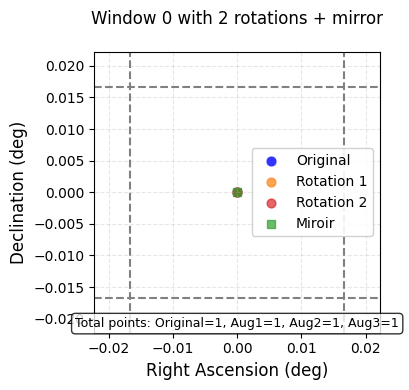

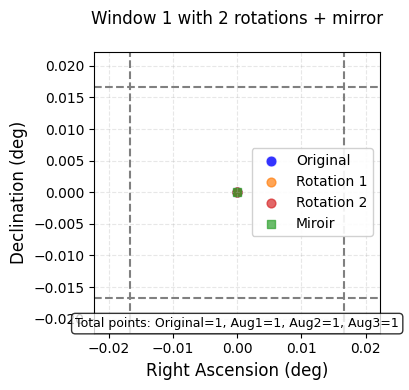

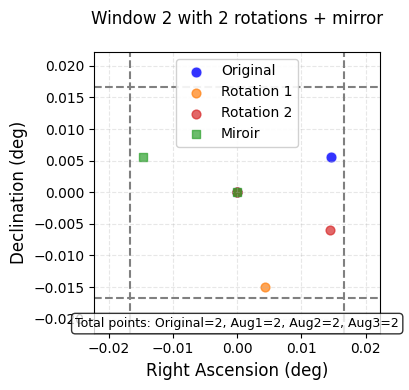

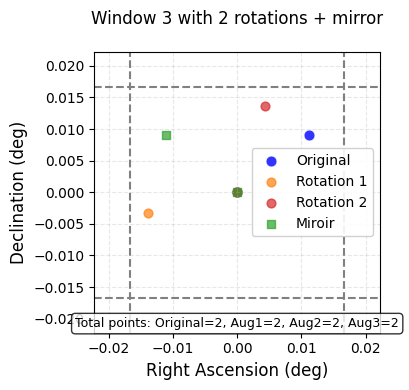

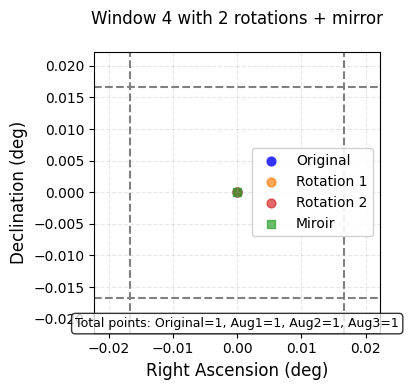

In [34]:
nbre2fenetres = 5
small_test     = list_windows_test[list_windows_test['window'] < nbre2fenetres]  # Prenez juste quelques fenêtres
small_clusters = info_clusters_test[info_clusters_test['window'] < nbre2fenetres]
small_AGN      = info_AGN_test[info_AGN_test['window'] < nbre2fenetres]
test_augm, clust_augm, agn_augm = random_rotations_and_mirror(small_test, small_clusters, small_AGN, 2)

print("Nombre total après augmentation:", len(test_augm))
for win_id in np.unique(small_test['window']):
    plot_augmentations(test_augm, win_id, small_test['window'].max(), 2)

# **Statistiques globales**

On determine ensuite les stats globales, necessaire pour la discretisation.

In [35]:
def compute_global_stats(data, selected_columns):

    global_stats = {}

    for col in selected_columns:
        if col in data.dtype.names:
            values = data[col][~np.isnan(data[col])]
            if len(values) > 0:
                global_stats[col] = {
                    'min': np.min(values),
                    'max': np.max(values),
                    'log_min': np.log10(np.min(values[values > 0]) if np.any(values > 0) else 1e-10)
                }

    return global_stats

In [36]:
global_stats_Xamin          = compute_global_stats(vstack([list_windows_train_augm, list_windows_test_augm]), SELECTED_COLUMNS_Xamin)
global_stats_input_clusters = compute_global_stats(vstack([info_clusters_train_augm, info_clusters_test_augm]), SELECTED_COLUMNS_input_clusters)
global_stats_input_AGN      = compute_global_stats(vstack([info_AGN_train_augm, info_AGN_test_augm]), SELECTED_COLUMNS_input_AGN)

# **Discretisation des donnees**

In [37]:
def discretise_et_complete(data_ref, data, n_bins, global_stats, selected_columns, log_scale_flags, PAD_TOKEN, max_sources):
    """
    Version optimisée pour la performance.
    """
    # Pré-calculs initiaux
    windows = []
    data_windows = set(np.unique(data['window']))
    ref_windows = np.unique(data_ref['window'])
    pad_length = len(selected_columns)
    empty_padding = [[PAD_TOKEN] * pad_length for _ in range(max_sources)]
    n_bins_minus_1 = n_bins - 1
    
    # Pré-calcul des paramètres de normalisation
    norm_params = []
    for col_idx, col in enumerate(selected_columns):
        stats = global_stats.get(col, {})
        use_log = log_scale_flags[col_idx] and col in global_stats
        if use_log:
            log_min = stats['log_min']
            log_range = np.log10(stats['max']) - log_min + 1e-10
            norm_params.append(('log', log_min, log_range))
        elif col in global_stats:
            min_val = stats['min']
            range_val = stats['max'] - min_val + 1e-10
            norm_params.append(('linear', min_val, range_val))
        else:
            norm_params.append(('none',))
    
    # Pré-allocation des tableaux
    for window_id in ref_windows:
        if data_ref is not data and window_id not in data_windows:
            windows.append(empty_padding.copy())
            continue
            
        win_data = data[data['window'] == window_id]
        win_features = []
        
        # Pré-allocation pour les sources
        for src in win_data:
            src_features = []
            for col_idx, col in enumerate(selected_columns):
                if col not in src.colnames:
                    src_features.append(PAD_TOKEN)
                    continue
                    
                val = src[col]
                if np.isnan(val) or np.isinf(val):
                    src_features.append(PAD_TOKEN)
                    continue
                    
                norm_type, *params = norm_params[col_idx]
                
                if norm_type == 'log':
                    safe_val = max(val, 1e-10) if val <= 0 else val
                    log_val = np.log10(safe_val)
                    norm_val = (log_val - params[0]) / params[1]
                elif norm_type == 'linear':
                    norm_val = (val - params[0]) / params[1]
                else:  # 'none'
                    norm_val = val
                
                discretized_val = int(np.clip(norm_val * n_bins_minus_1, 0, n_bins_minus_1))
                src_features.append(discretized_val)
            
            win_features.append(src_features)
        
        # Padding si nécessaire
        num_pad = max_sources - len(win_features)
        if num_pad > 0:
            current_pad_length = len(win_features[0]) if win_features else pad_length
            padding = [[PAD_TOKEN] * current_pad_length for _ in range(num_pad)]
            win_features.extend(padding)
        
        windows.append(win_features)
    
    return np.array(windows)

**Temps d'execution si 50% d'amas**

- 30s pour 200 rotations avec N>100ph avec MAX_Xamin_PAR_FENESTRON = 2

In [38]:
windows_test            = discretise_et_complete(list_windows_test_augm, list_windows_test_augm, int(VOCAB_SIZE-NOMBRE_TOKENS_SPECIAUX), global_stats_Xamin, SELECTED_COLUMNS_Xamin, use_log_scale_Xamin, PAD_TOKEN, MAX_SOURCES)
ClustersInWindows_test  = discretise_et_complete(list_windows_test_augm, info_clusters_test_augm, int(VOCAB_SIZE-NOMBRE_TOKENS_SPECIAUX), global_stats_input_clusters, SELECTED_COLUMNS_input_clusters, use_log_scale_input_clusters, PAD_TOKEN, MAX_CLUSTERS)
AGNInWindows_test       = discretise_et_complete(list_windows_test_augm, info_AGN_test_augm, int(VOCAB_SIZE-NOMBRE_TOKENS_SPECIAUX), global_stats_input_AGN, SELECTED_COLUMNS_input_AGN, use_log_scale_input_AGN, PAD_TOKEN, MAX_AGN )

**Temps d'execution si 50% d'amas**

- 4m pour 200 rotations avec N>100ph avec MAX_Xamin_PAR_FENESTRON = 2

In [39]:
windows_train           = discretise_et_complete(list_windows_train_augm, list_windows_train_augm, int(VOCAB_SIZE-NOMBRE_TOKENS_SPECIAUX), global_stats_Xamin, SELECTED_COLUMNS_Xamin, use_log_scale_Xamin, PAD_TOKEN, MAX_SOURCES)
ClustersInWindows_train = discretise_et_complete(list_windows_train_augm, info_clusters_train_augm, int(VOCAB_SIZE-NOMBRE_TOKENS_SPECIAUX), global_stats_input_clusters, SELECTED_COLUMNS_input_clusters, use_log_scale_input_clusters, PAD_TOKEN, MAX_CLUSTERS )
AGNInWindows_train      = discretise_et_complete(list_windows_train_augm, info_AGN_train_augm, int(VOCAB_SIZE-NOMBRE_TOKENS_SPECIAUX), global_stats_input_AGN, SELECTED_COLUMNS_input_AGN, use_log_scale_input_AGN, PAD_TOKEN, MAX_AGN )

In [40]:
print("\n=== TRAIN ===")
print(f"len(windows_train) = {len(windows_train)}")
print(f"len(ClustersInWindows_train) = {len(ClustersInWindows_train)}")
print(f"len(AGNInWindows_train) = {len(AGNInWindows_train)}")

print("\n=== TEST ===")
print(f"len(windows_test) = {len(windows_test)}")
print(f"len(ClustersInWindows_test) = {len(ClustersInWindows_test)}")
print(f"len(AGNInWindows_test) = {len(AGNInWindows_test)}")


=== TRAIN ===
len(windows_train) = 89486
len(ClustersInWindows_train) = 89486
len(AGNInWindows_train) = 89486

=== TEST ===
len(windows_test) = 21210
len(ClustersInWindows_test) = 21210
len(AGNInWindows_test) = 21210


# **Concatenation des donnees Xamin avec celles sur les amas**

In [41]:
def combine_and_flatten_with_special_tokens(windows_Xamin, windows_input_cluster, windows_input_AGN, 
                                            cls_token = CLS_TOKEN, sep_token = SEP_TOKEN, sep_amas_token = SEP_AMAS, sep_agn_token = SEP_AGN):
    """
    Returns 2D array of shape (n_windows, max_sources*n_features_Xamin + max_clusters*n_features_input_cluster + max_agn*n_features_input_agn + 2)
    """
    cls_token      = np.array(cls_token).flatten()
    sep_token      = np.array(sep_token).flatten()
    sep_amas_token = np.array(sep_amas_token).flatten()
    sep_agn_token  = np.array(sep_agn_token).flatten()

    if len(windows_Xamin) != len(windows_input_cluster) or len(windows_input_AGN) != len(windows_input_cluster):
        raise ValueError("Les trois listes de fenêtres doivent avoir la même longueur.")

    result = []
    for win_xamin, win_input_cluster, win_input_AGN in zip(windows_Xamin, windows_input_cluster, windows_input_AGN):
        win_xamin = np.array(win_xamin)
        win_input_cluster = np.array(win_input_cluster)
        win_input_AGN = np.array(win_input_AGN)
        seq = []
        seq.extend(cls_token)
        seq.extend(win_xamin.flatten())
        seq.extend(sep_amas_token)
        seq.extend(win_input_cluster.flatten())
        seq.extend(sep_agn_token)
        seq.extend(win_input_AGN.flatten())
        seq.extend(sep_token)
        result.append(seq)

    return np.array(result)

In [42]:
X_train = combine_and_flatten_with_special_tokens(windows_train, ClustersInWindows_train, AGNInWindows_train)
X_test = combine_and_flatten_with_special_tokens(windows_test, ClustersInWindows_test, AGNInWindows_test)

In [43]:
print(f"Dim de X_train: {X_train.shape}") # Devrait être (n_windows,  MAX_SOURCES * n_features_Xamin + MAX_CLUSTERS * n_features_input + 2)
print(f"Dim de X_test: {X_test.shape}") # Devrait être (n_windows,  MAX_SOURCES * n_features_Xamin + MAX_CLUSTERS * n_features_input + 2)

Dim de X_train: (89486, 24)
Dim de X_test: (21210, 24)


In [44]:
i_debut_amas = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + 2
i_debut_agn  = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_input_clusters) * MAX_CLUSTERS + 3
print(f'i_debut_amas = {i_debut_amas}')
print(f'i_debut_agn  = {i_debut_agn}')

print(f'\nX_test[0]  = {X_test[0]}')
print(f'X_test[0][i_debut_amas]  = {X_test[0][i_debut_amas]}')
print(f'X_test[0][i_debut_agn]  = {X_test[0][i_debut_agn]}')


i_debut_amas = 12
i_debut_agn  = 17

X_test[0]  = [1026  763  970  333  465  204 1024 1024 1024 1024 1024 1027  425  501
 1024 1024 1028 1024 1024 1024 1024 1024 1024 1025]
X_test[0][i_debut_amas]  = 425
X_test[0][i_debut_agn]  = 1024


# **Sauvegarde des donnees**

**Sauvegarde des donnees sequences d'entrainement et test**

In [45]:
np.savetxt(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/X_train.txt', X_train, fmt='%d')
np.savetxt(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/X_test.txt', X_test, fmt='%d')

**Sauvegarde des statistiques globales**

In [46]:
# Création du dictionnaire
constantes_du_modele = {
    "VOCAB_SIZE": VOCAB_SIZE,
    "PAD_TOKEN": PAD_TOKEN,
    "SEP_TOKEN": SEP_TOKEN,
    "CLS_TOKEN": CLS_TOKEN,
    "SEP_AMAS": SEP_AMAS,
    "SEP_AGN": SEP_AGN,
    "NOMBRE_TOKENS_SPECIAUX": NOMBRE_TOKENS_SPECIAUX,
    "MAX_SOURCES": int(MAX_SOURCES),
    "MAX_CLUSTERS": int(MAX_CLUSTERS),
    "MAX_AGN": int(MAX_AGN)
}

# Sauvegarde en JSON
save_path = f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/constantes_du_modele.json"
with open(save_path, 'w') as f:
    json.dump(constantes_du_modele, f, indent=4)

print(f"Dictionnaire sauvegardé dans {save_path}")

Dictionnaire sauvegardé dans /local/home/sh275430/Documents/TransformerSurFenestrons/results/Simulation1/constantes_du_modele.json


**Sauvegarde des statistiques globales**

In [47]:
save_path = f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/global_stats_Xamin.json"
with open(save_path, 'w') as f:
    json.dump(global_stats_Xamin, f, indent=4)
print(f"Dictionnaire sauvegardé dans {save_path}")

save_path = f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/global_stats_input_clusters.json"
with open(save_path, 'w') as f:
    json.dump(global_stats_input_clusters, f, indent=4)
print(f"Dictionnaire sauvegardé dans {save_path}")


Dictionnaire sauvegardé dans /local/home/sh275430/Documents/TransformerSurFenestrons/results/Simulation1/global_stats_Xamin.json
Dictionnaire sauvegardé dans /local/home/sh275430/Documents/TransformerSurFenestrons/results/Simulation1/global_stats_input_clusters.json


In [48]:
def convert_numpy_types(obj):
    """Convertit les types NumPy en types natifs Python pour la sérialisation JSON"""
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_numpy_types(value) for key, value in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_numpy_types(item) for item in obj]
    return obj

# Avant de sauvegarder, convertissez vos données
global_stats_serializable = convert_numpy_types(global_stats_input_AGN)

save_path = f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/global_stats_input_AGN.json"
with open(save_path, 'w') as f:
    json.dump(global_stats_serializable, f, indent=4, ensure_ascii=False)
print(f"Dictionnaire sauvegardé dans {save_path}")


Dictionnaire sauvegardé dans /local/home/sh275430/Documents/TransformerSurFenestrons/results/Simulation1/global_stats_input_AGN.json


_______
_______
_______

In [49]:
def ExtractionOutput(table_seq, type):

    if type == 'AMAS':
        indice_debut = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + 2 # +2 pour les tokens de debut de sequence et celui du catalogue d'amas
        indice_fin   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_input_clusters) * MAX_CLUSTERS +1 # +1 pour marquer le debut du catalogue d'amas
        n_rows = len(table_seq) * MAX_CLUSTERS  # Nombre de lignes du nouveau tableau
        keys = {'RA' : 'R.A.', 'DEC' : 'Dec'}
        
    elif type == 'AGN':
        indice_debut = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_input_clusters) * MAX_CLUSTERS + 3  # +2 pour les tokens de debut de sequence et celui du catalogue d'amas ET celui AGN
        indice_fin   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_input_clusters) * MAX_CLUSTERS + len(SELECTED_COLUMNS_input_AGN) * MAX_AGN +1
        n_rows = len(table_seq) * MAX_AGN  # Nombre de lignes du nouveau tableau
        keys = {'RA' : 'ra_mag_gal', 'DEC' :'dec_mag_gal'}


    liste_ra_dec = table_seq[:,indice_debut: indice_fin + 1] #+1 a cause de la convention en python

    # Création du tableau
    table = np.zeros((n_rows, 3), dtype=np.int64)  # Initialisation à 0 partout
    table[:, 1:] = PAD_TOKEN  # RA et DEC remplis avec PAD_TOKEN
    table_cols = {'num_window': 0, 'RA': 1, 'DEC': 2} # Nommage des colonnes

    row_index = 0
    for i, win in enumerate(liste_ra_dec):
        for ra, dec in zip(win[::2], win[1::2]):
            table[row_index, table_cols['num_window']] = i
            table[row_index, table_cols['RA']] = ra
            table[row_index, table_cols['DEC']] = dec
            row_index += 1

    mask = np.logical_and(table[:, 1] != PAD_TOKEN, table[:, 2] != PAD_TOKEN)
    filtered_table = table[mask]

    return filtered_table


In [50]:
table_AMAS = ExtractionOutput(X_test, 'AMAS')
table_AGN  = ExtractionOutput(X_test, 'AGN')

In [51]:
num_fenetre = random.randint(0, 100)

print(f"\033[1mFenestron {num_fenetre}:\033[0m")

#print("\n\033[1mSequence complete:\033[0m")
print(X_test[num_fenetre])

indice_debut_AMAS = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + 2
indice_fin_AMAS   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_input_clusters) * MAX_CLUSTERS +1

print("\n\033[1m - Catalogue AMAS:\033[0m")
print(X_test[num_fenetre,indice_debut_AMAS:indice_fin_AMAS+1])

indice_debut_AGN = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_input_clusters) * MAX_CLUSTERS + 3 
indice_fin_AGN   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_input_clusters) * MAX_CLUSTERS + len(SELECTED_COLUMNS_input_AGN) * MAX_AGN + 2

print("\n\033[1m - Catalogue AGN:\033[0m")
print(X_test[num_fenetre,indice_debut_AGN:indice_fin_AGN+1])

print("\n\033[1m - Catalogue AMAS extrait par la fonction:\033[0m")
print(table_AMAS[table_AMAS[:, 0] == num_fenetre])

print("\n\033[1m - Catalogue AGN extrait par la fonction:\033[0m")
print(table_AGN[table_AGN[:, 0] == num_fenetre])

Fenestron 42:
[1026  633  557  519  517  431 1024 1024 1024 1024 1024 1027  549  515
 1024 1024 1028  507  510 1024 1024 1024 1024 1025]

 - Catalogue AMAS:
[ 549  515 1024 1024]

 - Catalogue AGN:
[ 507  510 1024 1024 1024 1024]

 - Catalogue AMAS extrait par la fonction:
[[ 42 549 515]]

 - Catalogue AGN extrait par la fonction:
[[ 42 507 510]]
